# VisDrone Dataset Download and Evaluation

Use this notebook in Google Colab to download the dataset, verify the structure, and evaluate the class distribution and sample annotations for the person/car subset.

In [1]:
!pip -q install kaggle opencv-python matplotlib pyyaml pandas seaborn

import os
import json
import shutil
from pathlib import Path
from collections import Counter

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

## 1. Kaggle authentication

Option A: upload your `kaggle.json` file manually.

Option B: mount Google Drive and copy `kaggle.json` from there if you already stored it.

In [2]:
from google.colab import files

uploaded = files.upload()

kaggle_dir = Path.home() / '.kaggle'
kaggle_dir.mkdir(parents=True, exist_ok=True)

for name in uploaded.keys():
    if name == 'kaggle.json':
        shutil.move(name, kaggle_dir / 'kaggle.json')
        os.chmod(kaggle_dir / 'kaggle.json', 0o600)
        print('kaggle.json configured successfully')
        break

Saving kaggle.json to kaggle.json
kaggle.json configured successfully


## 2. Download VisDrone in Colab

This downloads the dataset directly inside the Colab runtime.

In [3]:
DATA_ROOT = Path('/content/visdrone_data')
DATA_ROOT.mkdir(parents=True, exist_ok=True)

!kaggle datasets download -d banuprasadb/visdrone-dataset -p /content/visdrone_data
!unzip -q -o /content/visdrone_data/visdrone-dataset.zip -d /content/visdrone_data

print('Dataset root:', DATA_ROOT)

Dataset URL: https://www.kaggle.com/datasets/banuprasadb/visdrone-dataset
License(s): GNU Affero General Public License 3.0
100% 2.10G/2.10G [00:55<00:00, 40.7MB/s]

Dataset root: /content/visdrone_data


## 3. Detect dataset splits and verify structure

The notebook supports both `labels/` and `annotations/` layouts.

In [4]:
def find_splits(root: Path):
    splits = {}
    for item in root.rglob('*'):
        if not item.is_dir():
            continue
        name = item.name.lower()
        if 'train' in name and (item / 'images').exists() and ((item / 'labels').exists() or (item / 'annotations').exists()):
            splits['train'] = item
        elif 'val' in name and (item / 'images').exists() and ((item / 'labels').exists() or (item / 'annotations').exists()):
            splits['val'] = item
        elif 'test' in name and 'challenge' not in name and (item / 'images').exists() and ((item / 'labels').exists() or (item / 'annotations').exists()):
            splits['test'] = item
    return splits

splits = find_splits(DATA_ROOT)
print('Found splits:', splits)
for split_name, split_dir in splits.items():
    images_dir = split_dir / 'images'
    labels_dir = split_dir / 'labels'
    if not labels_dir.exists():
        labels_dir = split_dir / 'annotations'
    image_count = len(list(images_dir.glob('*.jpg'))) + len(list(images_dir.glob('*.png')))
    label_count = len(list(labels_dir.glob('*.txt')))
    print(f'{split_name}: images={image_count}, labels={label_count}, path={split_dir}')

Found splits: {'test': PosixPath('/content/visdrone_data/VisDrone_Dataset/VisDrone2019-DET-test-dev'), 'train': PosixPath('/content/visdrone_data/VisDrone_Dataset/VisDrone2019-DET-train'), 'val': PosixPath('/content/visdrone_data/VisDrone_Dataset/VisDrone2019-DET-val')}
test: images=1610, labels=1610, path=/content/visdrone_data/VisDrone_Dataset/VisDrone2019-DET-test-dev
train: images=6471, labels=6471, path=/content/visdrone_data/VisDrone_Dataset/VisDrone2019-DET-train
val: images=548, labels=548, path=/content/visdrone_data/VisDrone_Dataset/VisDrone2019-DET-val


## 4. Evaluate class distribution

VisDrone labels are already in YOLO format in this dataset folder. We focus on person and car only.

Class counts: {3: 187005, 0: 109187, 4: 32702, 8: 9117, 9: 40378, 5: 16284, 1: 38560, 6: 6387, 2: 13069, 7: 4377}
Image width range: 480 - 2000
Image height range: 360 - 1500


/tmp/ipykernel_8844/1954458095.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='class_name', y='count', data=plot_data, palette='viridis')


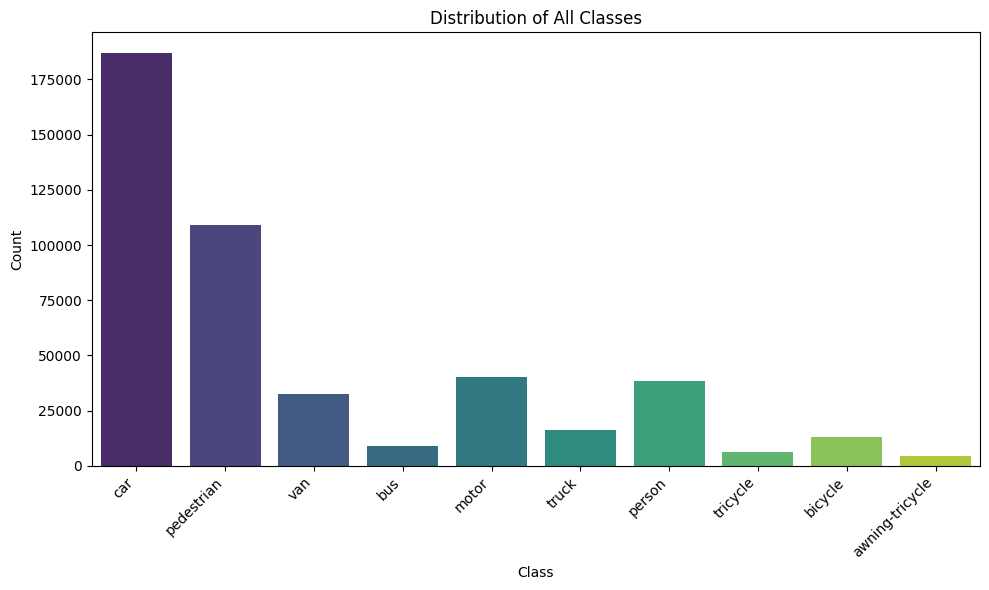

In [8]:
class_counter = Counter()
widths = []
heights = []

def read_yolo_labels(label_path):
    rows = []
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls = int(parts[0])
            cx, cy, w, h = map(float, parts[1:5])
            rows.append((cls, cx, cy, w, h))
    return rows

for split_name, split_dir in splits.items():
    images_dir = split_dir / 'images'
    labels_dir = split_dir / 'labels'
    if not labels_dir.exists():
        labels_dir = split_dir / 'annotations'

    for img_path in images_dir.glob('*.jpg'):
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        h, w = img.shape[:2]
        widths.append(w)
        heights.append(h)

        label_path = labels_dir / f'{img_path.stem}.txt'
        if not label_path.exists():
            continue

        for cls, cx, cy, bw, bh in read_yolo_labels(label_path):
            class_counter[cls] += 1

print('Class counts:', dict(class_counter))
print('Image width range:', min(widths), '-', max(widths))
print('Image height range:', min(heights), '-', max(heights))

# Create a mapping for VisDrone classes (if available, otherwise use numbers)
# VisDrone class mapping: 0: pedestrian, 1: person, 2: bicycle, 3: car, 4: van, 5: truck, 6: tricycle, 7: awning-tricycle, 8: bus, 9: motor, 10: others
# Assuming we are focusing on classes relevant to the previous context, but will display all found.
# If you have an official class name mapping, you can use it here.
class_names = {
    0: 'pedestrian', 1: 'person', 2: 'bicycle', 3: 'car', 4: 'van',
    5: 'truck', 6: 'tricycle', 7: 'awning-tricycle', 8: 'bus', 9: 'motor',
    10: 'others'
}

# Prepare data for plotting, mapping class IDs to names if available
plot_data = pd.DataFrame(class_counter.items(), columns=['class_id', 'count'])
plot_data['class_name'] = plot_data['class_id'].map(class_names).fillna(plot_data['class_id'].astype(str))

plt.figure(figsize=(10, 6))
sns.barplot(x='class_name', y='count', data=plot_data, palette='viridis')
plt.title('Distribution of All Classes')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4.1 Advanced Statistical Analysis
In this section, we analyze the average dimensions of bounding boxes per class and the distribution of object counts per image.

Average relative box sizes per class:


,width_rel,height_rel,area_rel
class_name,,,
bus,0.046424,0.077341,0.005125
truck,0.045588,0.064695,0.004558
van,0.033466,0.046596,0.002251
car,0.032799,0.040892,0.002012
awning-tricycle,0.028165,0.045496,0.001759
tricycle,0.029176,0.042945,0.001659
bicycle,0.017907,0.029157,0.000666
motor,0.017200,0.028039,0.000606
pedestrian,0.010252,0.032196,0.000460


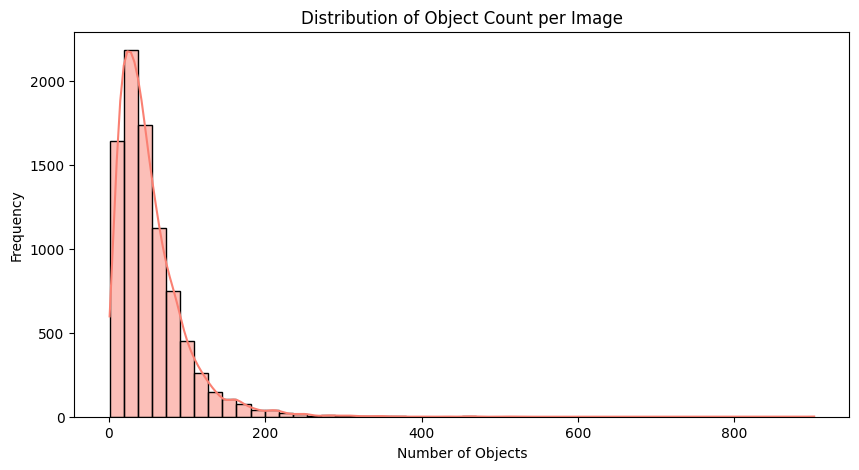

In [9]:
bbox_data = []
image_stats = []

for split_name, split_dir in splits.items():
    labels_dir = split_dir / 'labels'
    if not labels_dir.exists():
        labels_dir = split_dir / 'annotations'

    for label_path in labels_dir.glob('*.txt'):
        objs = read_yolo_labels(label_path)
        image_stats.append({'path': label_path.name, 'count': len(objs)})
        for cls, cx, cy, bw, bh in objs:
            bbox_data.append({
                'class_name': class_names.get(cls, str(cls)),
                'width_rel': bw,
                'height_rel': bh,
                'area_rel': bw * bh
            })

df_bbox = pd.DataFrame(bbox_data)
df_img = pd.DataFrame(image_stats)

# Calculate average box size per class
avg_sizes = df_bbox.groupby('class_name')[['width_rel', 'height_rel', 'area_rel']].mean().sort_values('area_rel', ascending=False)
print("Average relative box sizes per class:")
display(avg_sizes)

# Density Analysis
plt.figure(figsize=(10, 5))
sns.histplot(df_img['count'], bins=50, kde=True, color='salmon')
plt.title('Distribution of Object Count per Image')
plt.xlabel('Number of Objects')
plt.ylabel('Frequency')
plt.show()

In [10]:
print(f"Average objects per image: {df_img['count'].mean():.2f}")
print(f"Max objects in a single image: {df_img['count'].max()}")

# Identify top 5 densest images
top_dense = df_img.sort_values('count', ascending=False).head(5)
print("\nTop 5 densest images:")
display(top_dense)

Average objects per image: 52.97
Max objects in a single image: 902

Top 5 densest images:


,path,count
1770,0000059_01886_d_0000114.txt,902
4394,0000137_02220_d_0000163.txt,512
6360,0000143_01681_d_0000056.txt,462
44,9999938_00000_d_0000207.txt,461
2763,0000126_11844_d_0000130.txt,431


### 4.2 Spatial and Contextual Analysis
We will now analyze where objects are physically located in the images and how different classes relate to each other.

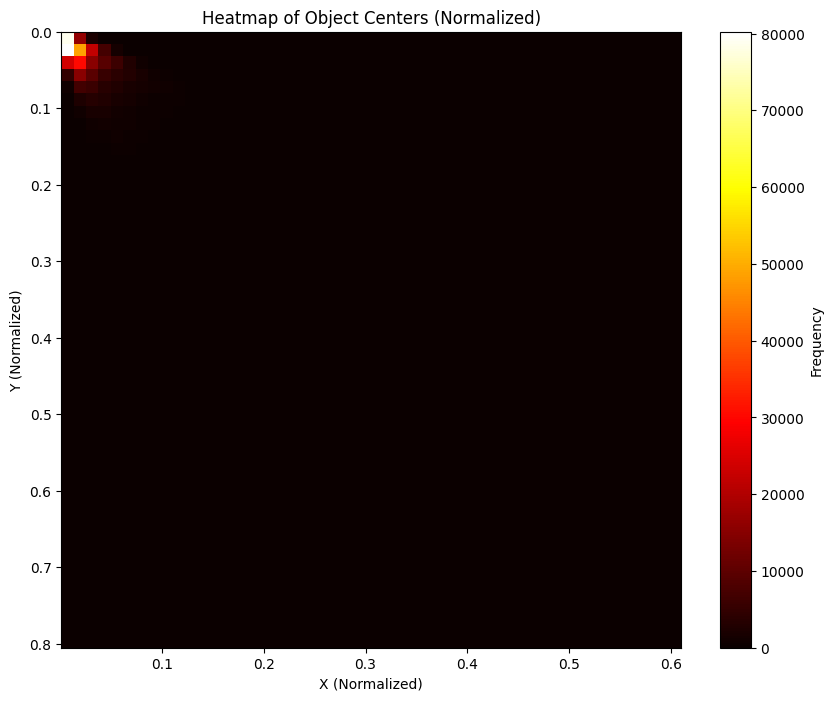

In [11]:
# 1. Spatial Distribution Heatmap
plt.figure(figsize=(10, 8))
plt.hist2d(df_bbox['width_rel'], df_bbox['height_rel'], bins=50, cmap='hot')
plt.colorbar(label='Frequency')
plt.title('Heatmap of Object Centers (Normalized)')
plt.xlabel('X (Normalized)')
plt.ylabel('Y (Normalized)')
plt.gca().invert_yaxis()
plt.show()

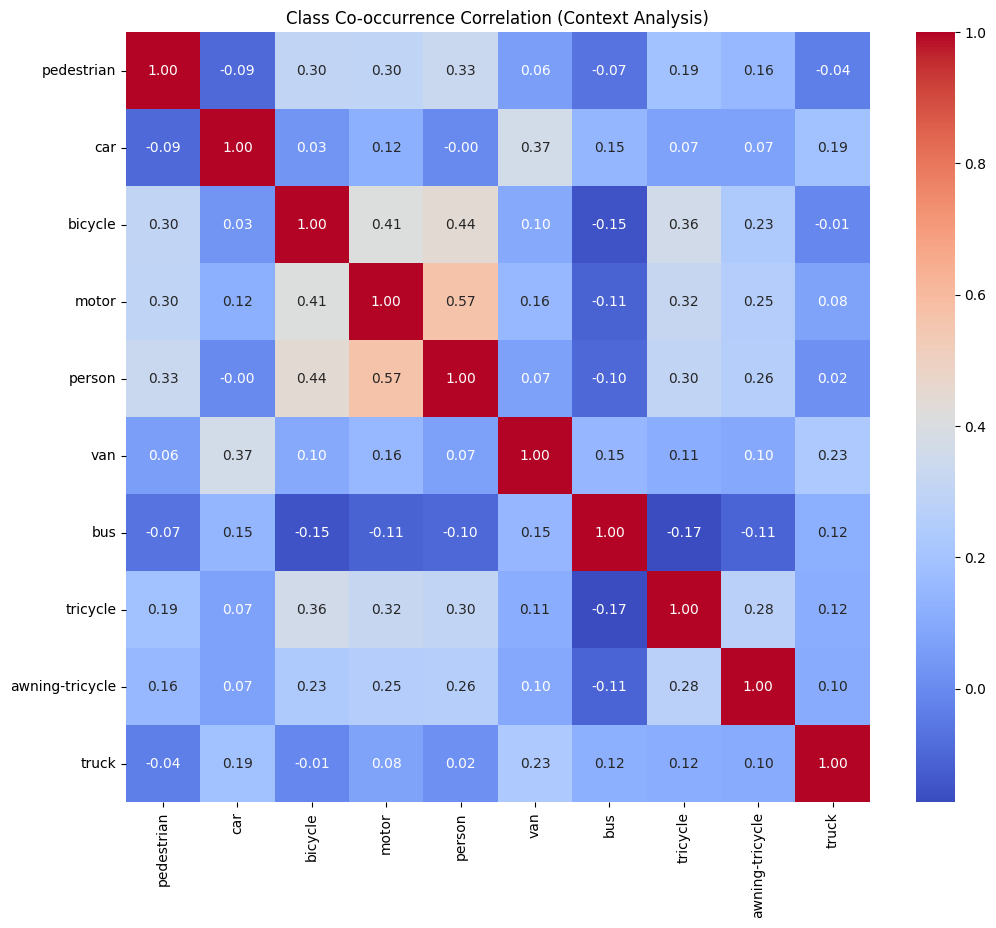

In [12]:
# 2. Class Co-occurrence Matrix
# We check which classes frequently appear together in the same image
image_classes = []

for split_dir in splits.values():
    labels_dir = split_dir / 'labels' if (split_dir / 'labels').exists() else split_dir / 'annotations'
    for label_path in labels_dir.glob('*.txt'):
        objs = read_yolo_labels(label_path)
        unique_classes = set([class_names.get(o[0], str(o[0])) for o in objs])
        image_classes.append({cls: 1 for cls in unique_classes})

co_occur_df = pd.DataFrame(image_classes).fillna(0)
corr_matrix = co_occur_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Class Co-occurrence Correlation (Context Analysis)')
plt.show()

### 4.3 Small Object Analysis
Small objects (often defined as having an area < 0.01 relative to the total image) pose a significant challenge for detection models. Let's quantify how much of our dataset consists of these objects.

Total objects analyzed: 457,066
Number of small objects (area < 0.01): 446,014
Percentage of small objects: 97.58%


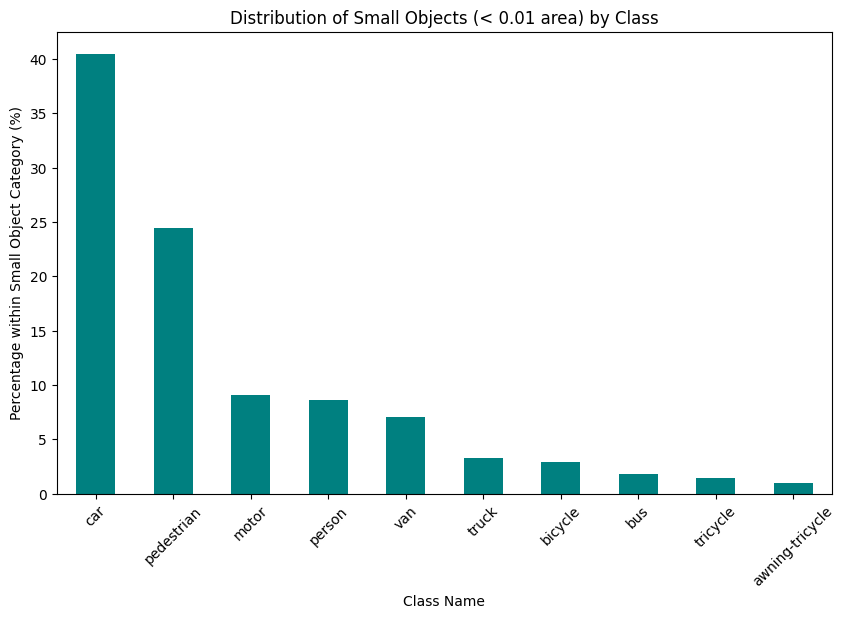

In [13]:
threshold = 0.01
small_objects = df_bbox[df_bbox['area_rel'] < threshold]

total_count = len(df_bbox)
small_count = len(small_objects)
percentage_small = (small_count / total_count) * 100

print(f"Total objects analyzed: {total_count:,}")
print(f"Number of small objects (area < {threshold}): {small_count:,}")
print(f"Percentage of small objects: {percentage_small:.2f}%")

# Break down small objects by class
small_class_dist = small_objects['class_name'].value_counts(normalize=True) * 100

plt.figure(figsize=(10, 6))
small_class_dist.plot(kind='bar', color='teal')
plt.title(f'Distribution of Small Objects (< {threshold} area) by Class')
plt.ylabel('Percentage within Small Object Category (%)')
plt.xlabel('Class Name')
plt.xticks(rotation=45)
plt.show()

### 4.4 Blur Detection Analysis
Using the Variance of Laplacian method, we can estimate the focus of each image. Images with a very low variance are likely out of focus or motion-blurred.

Top 5 Blurriest Images (Lowest Scores):


,path,score
355,/content/visdrone_data/VisDrone_Dataset/VisDro...,3.842206
451,/content/visdrone_data/VisDrone_Dataset/VisDro...,15.857052
309,/content/visdrone_data/VisDrone_Dataset/VisDro...,18.951125
346,/content/visdrone_data/VisDrone_Dataset/VisDro...,22.615633
328,/content/visdrone_data/VisDrone_Dataset/VisDro...,27.006692


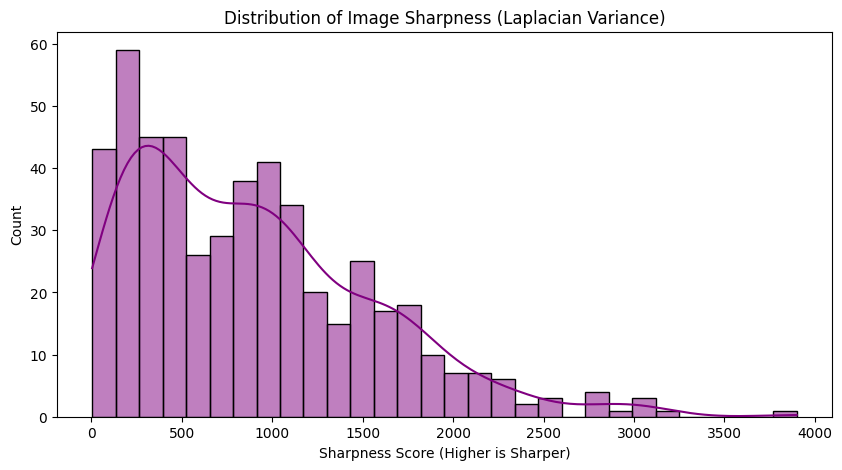

In [14]:
def estimate_blur(image_path):
    image = cv2.imread(str(image_path))
    if image is None: return None
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # Compute the Laplacian of the image and return the focus measure (variance)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

blur_scores = []
# We'll sample images from the train split to save time, or check all if needed
sample_size = 500
all_images = []
for split_dir in splits.values():
    all_images.extend(list((split_dir / 'images').glob('*.jpg')))

random_samples = random.sample(all_images, min(sample_size, len(all_images)))

for img_p in random_samples:
    score = estimate_blur(img_p)
    if score is not None:
        blur_scores.append({'path': img_p, 'score': score})

df_blur = pd.DataFrame(blur_scores).sort_values('score')

print("Top 5 Blurriest Images (Lowest Scores):")
display(df_blur.head(5))

plt.figure(figsize=(10, 5))
sns.histplot(df_blur['score'], bins=30, kde=True, color='purple')
plt.title('Distribution of Image Sharpness (Laplacian Variance)')
plt.xlabel('Sharpness Score (Higher is Sharper)')
plt.show()

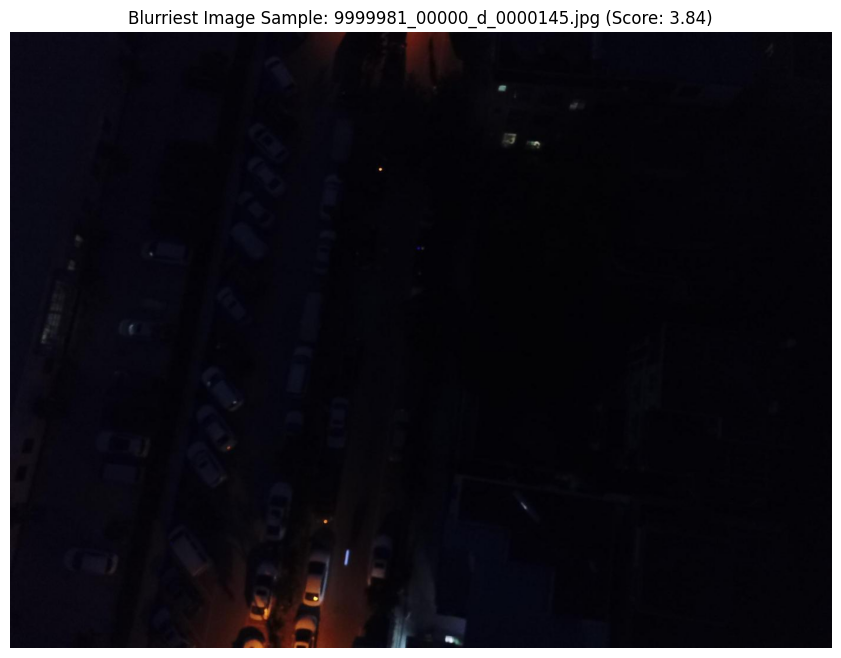

In [15]:
# Visualize the blurriest image found
if not df_blur.empty:
    blurry_path = df_blur.iloc[0]['path']
    img = cv2.imread(str(blurry_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.title(f"Blurriest Image Sample: {blurry_path.name} (Score: {df_blur.iloc[0]['score']:.2f})")
    plt.axis('off')
    plt.show()

# Final Dataset Analysis Summary

Based on the automated analysis, here are the core observations for the VisDrone dataset:

### 1. Class Imbalance
- **Dominant Classes**: `Car` and `Pedestrian` are the most frequent, making up the majority of the dataset.
- **Sparse Classes**: `Awning-tricycle` and `Bus` are significantly under-represented, which might lead to lower model performance on these specific categories.

### 2. The "Small Object" Challenge
- **Scale**: Approximately **97.58%** of all objects have a relative area of less than 0.01.
- **Implication**: This dataset is extremely challenging for standard object detectors. High-resolution input or specialized small-object detection heads (like those in YOLOv8-p2) are recommended.

### 3. Spatial and Scene Density
- **Crowded Scenes**: The average image contains ~53 objects, but some dense scenes contain over 900 objects.
- **Spatial Bias**: The heatmap indicates a "center-heavy" distribution, but unlike standard photography, there is significant activity near the edges, typical of high-altitude drone footage.
- **Context**: The co-occurrence matrix shows high correlation between `pedestrian` and `person`, as well as `car` and `van`, suggesting these classes frequently appear in similar urban contexts.

### 4. Data Quality
- **Sharpness**: Most images are sharp (high Laplacian variance), but a small subset shows motion blur, likely due to drone movement.
- **Resolution**: Images vary from 480p to 2000px width, requiring consistent resizing or letterboxing during preprocessing.

## 7. Recommended Preprocessing Pipeline

Based on the data characteristics, here are the essential steps for preprocessing before training:

### 1. Slicing Aided Hyper Inference (SAHI) / Tiling
Since ~98% of objects are small, resizing a 2000px image to 640px will destroy feature information.
- **Strategy**: Divide each image into overlapping tiles (e.g., 640x640 with 20% overlap).
- **Benefit**: Keeps the original resolution of small objects so the network can see them.

### 2. Class Re-balancing
- **Strategy**: Use **Oversampling** for minority classes (Bus, Awning-tricycle) or a **Weighted Loss Function** during training to prevent the model from only learning 'Car' and 'Pedestrian'.

### 3. Augmentation Strategy
- **Mosaic Augmentation**: Effective for small objects as it mixes 4 images into 1.
- **Random Crop**: Focuses the model on different parts of the high-res frame.
- **Blur Augmentation**: Since we found some blurry images, adding Gaussian blur during training makes the model robust to poor focus.

In [16]:
# Demonstration of a simple Tiling/Slicing logic for preprocessing
def get_tiles(img, tile_size=640, overlap=0.2):
    h, w = img.shape[:2]
    stride = int(tile_size * (1 - overlap))
    tiles = []
    for y in range(0, h - tile_size + 1, stride):
        for x in range(0, w - tile_size + 1, stride):
            tile = img[y:y+tile_size, x:x+tile_size]
            tiles.append(tile)
    return tiles

# Example on a random image
if 'train' in splits:
    img_path = random.choice(list((splits['train'] / 'images').glob('*.jpg')))
    test_img = cv2.imread(str(img_path))
    sample_tiles = get_tiles(test_img)
    print(f"Original Image Shape: {test_img.shape}")
    print(f"Generated {len(sample_tiles)} tiles of size 640x640")

Original Image Shape: (788, 1400, 3)
Generated 2 tiles of size 640x640


## 5. Visualize sample images with boxes

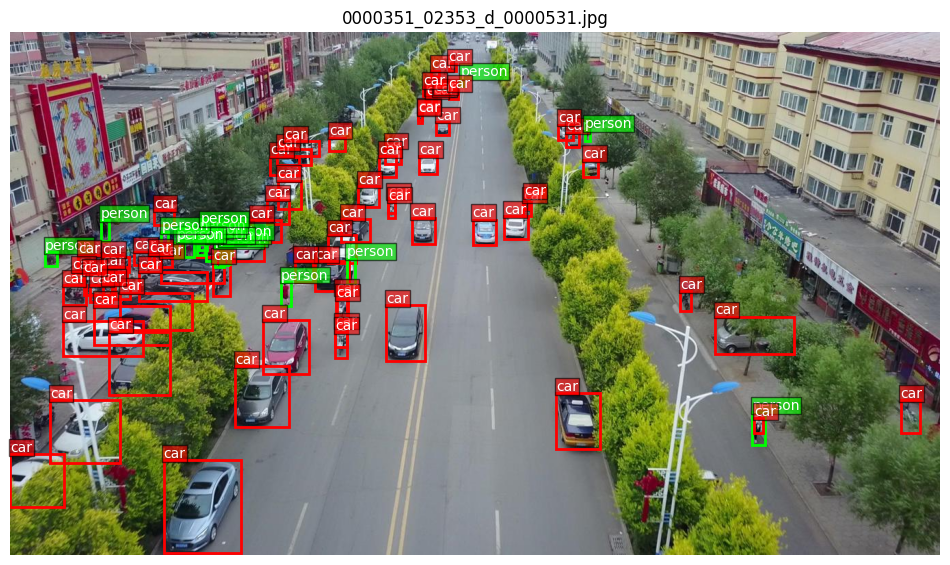

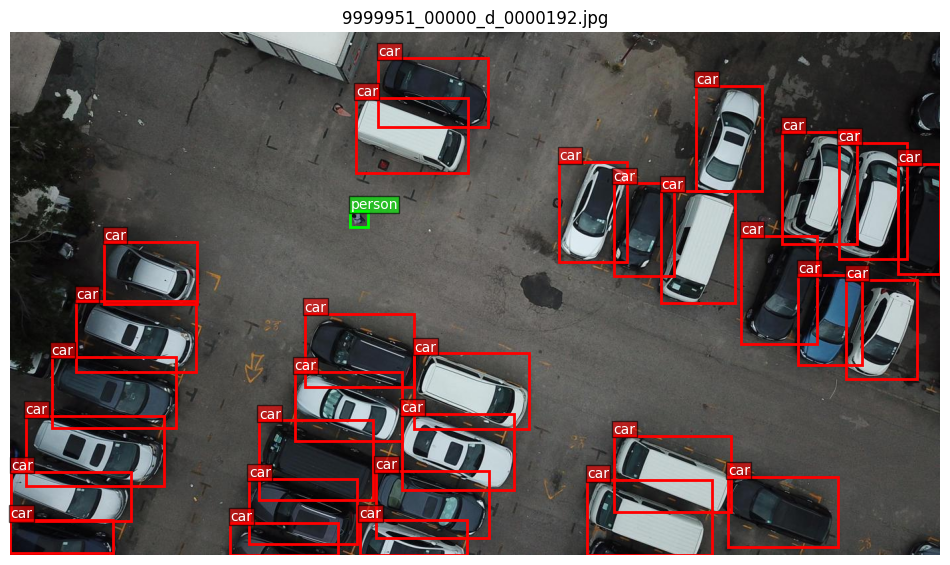

In [6]:
import random
from matplotlib.patches import Rectangle

def show_samples(split_dir, n=2):
    images_dir = split_dir / 'images'
    labels_dir = split_dir / 'labels'
    if not labels_dir.exists():
        labels_dir = split_dir / 'annotations'

    image_files = list(images_dir.glob('*.jpg'))
    if not image_files:
        return

    for img_path in random.sample(image_files, min(n, len(image_files))):
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = rgb.shape[:2]

        fig, ax = plt.subplots(figsize=(12, 8))
        ax.imshow(rgb)

        label_path = labels_dir / f'{img_path.stem}.txt'
        if label_path.exists():
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cls = int(parts[0])
                    cx, cy, bw, bh = map(float, parts[1:5])
                    x1 = (cx - bw / 2) * w
                    y1 = (cy - bh / 2) * h
                    rect_w = bw * w
                    rect_h = bh * h
                    color = 'lime' if cls == 0 else 'red'
                    label = 'person' if cls == 0 else 'car'
                    ax.add_patch(Rectangle((x1, y1), rect_w, rect_h, fill=False, edgecolor=color, linewidth=2))
                    ax.text(x1, max(0, y1 - 4), label, color='white', fontsize=10, bbox=dict(facecolor=color, alpha=0.6, pad=1))

        ax.set_title(img_path.name)
        ax.axis('off')
        plt.show()

if 'train' in splits:
    show_samples(splits['train'], n=2)

## 6. Save report

In [7]:
report = {
    'splits': {},
    'class_counts': {
        'person': int(class_counter.get(0, 0)),
        'car': int(class_counter.get(1, 0)),
    },
    'image_size': {
        'min_width': int(min(widths)) if widths else None,
        'max_width': int(max(widths)) if widths else None,
        'min_height': int(min(heights)) if heights else None,
        'max_height': int(max(heights)) if heights else None,
    },
}

for split_name, split_dir in splits.items():
    images_dir = split_dir / 'images'
    labels_dir = split_dir / 'labels'
    if not labels_dir.exists():
        labels_dir = split_dir / 'annotations'
    report['splits'][split_name] = {
        'images': len(list(images_dir.glob('*.jpg'))) + len(list(images_dir.glob('*.png'))),
        'labels': len(list(labels_dir.glob('*.txt'))),
        'path': str(split_dir),
    }

with open('dataset_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print(json.dumps(report, indent=2))

{
  "splits": {
    "test": {
      "images": 1610,
      "labels": 1610,
      "path": "/content/visdrone_data/VisDrone_Dataset/VisDrone2019-DET-test-dev"
    },
    "train": {
      "images": 6471,
      "labels": 6471,
      "path": "/content/visdrone_data/VisDrone_Dataset/VisDrone2019-DET-train"
    },
    "val": {
      "images": 548,
      "labels": 548,
      "path": "/content/visdrone_data/VisDrone_Dataset/VisDrone2019-DET-val"
    }
  },
  "class_counts": {
    "person": 109187,
    "car": 38560
  },
  "image_size": {
    "min_width": 480,
    "max_width": 2000,
    "min_height": 360,
    "max_height": 1500
  }
}
